In [4]:
#이전 학습에서 배웠던 다양한 Data cleaning 기술을 활용하여 cleaning된 나만의 데이터를 만들고 정리
#이번 프로젝트에서 사용할 데이터 이름은 trip.csv입니다. “택시 요금”을 예측한다는 가정하에 데이터 정제

#1. 결측치 판단 및 처리//결측치의 유무와 비율을 살펴보고 적절한 방법으로 처리합니다.
# 파일 불러오기
# 결측치 개수 확인하기
# 결측 비율 확인하기
# 결측이 있는 행을 출력하기
# 제거or평균or중간값 넣을지 파악후, 실행
#2. 이상치 판단 및 처리//자형 변수 각각에 대해, 데이터의 index와 변수 값 사이의 scatter plot을 그려보고 이상치가 관찰될 경우 제거

#추가실습
#3. 택시 탑승 및 하차 시간 활용할 수 있을지 고민. // 택시의 주행 시간과 주행 거리, 요금 등의 상관 관계도 살펴볼 수 있겠죠?

#4. Credit Card와 Debit Card를 구분없이 "Card"라는 이름으로 만들어 보세요.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#from google.colab import drive
#drive.mount('/content/drive')
#df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/택시trip.csv')

df = pd.read_csv('./taxi_trip.csv')

In [6]:
df.head()

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
0,Pamela Duffy,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,Debit Card,6,3.34,13.0,2.76,0.0
1,Michelle Foster,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,Debit Card,1,1.80,16.0,4.00,0.0
2,Tina Combs,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,Debit Card,1,1.00,6.5,1.45,0.0
3,Anthony Ray,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,Cash,1,3.70,20.5,6.39,0.0
4,Brianna Johnson,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,Debit Card,1,4.37,16.5,0.00,0.0


In [7]:
# 데이터의 열의 이름을 정리해줬음.

df = df.rename(columns={
    'passenger_name': '승객이름',
    "tpep_pickup_datetime": "승차시각",
    "tpep_dropoff_datetime": "하차시각",
    "payment_method": "결제방식",
    "passenger_count": "승객수",
    "trip_distance": "이동거리",
    "fare_amount": "요금",
    "tip_amount": "팁",
    "tolls_amount": "톨비"
    })

C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


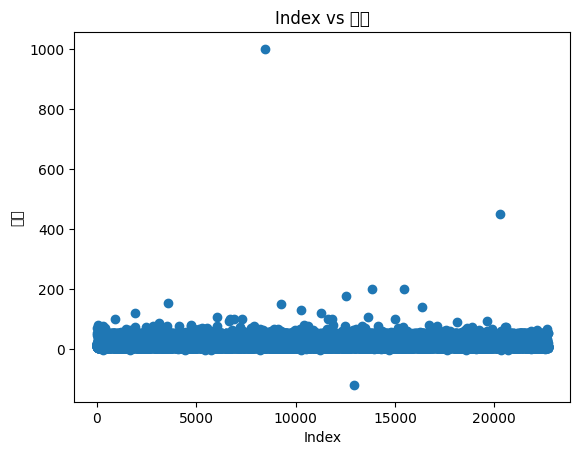

C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


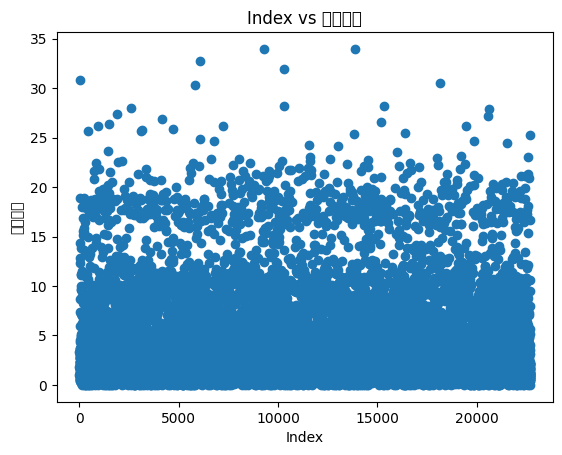

C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54017 (\N{HANGUL SYLLABLE TIB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


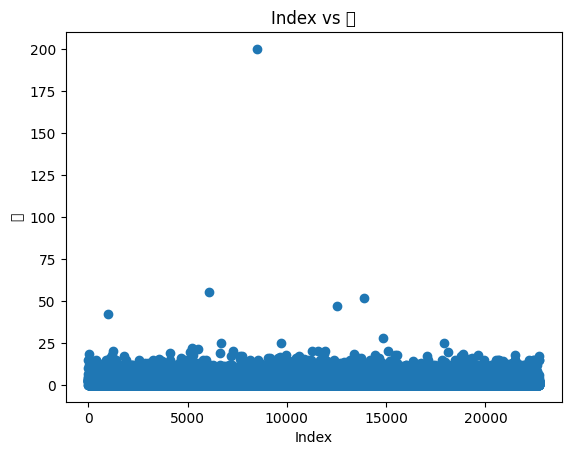

C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53672 (\N{HANGUL SYLLABLE TOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


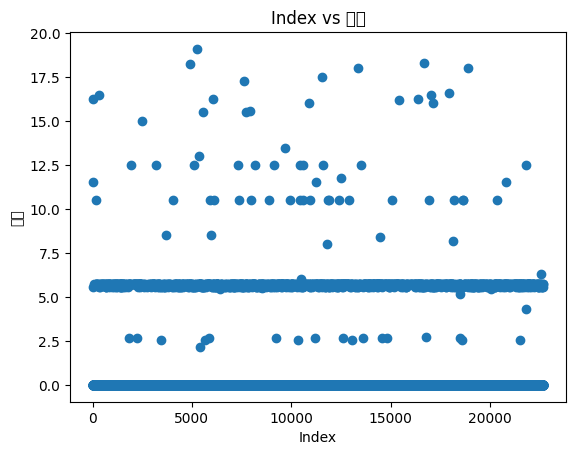

In [8]:
plt.scatter(df.index, df['요금']) #산점도로 분포를 보고 이상치를 조건으로 제거해볼 계획.
plt.title('Index vs 요금')
plt.xlabel('Index')
plt.ylabel('요금')
plt.show()

plt.scatter(df.index, df['이동거리'])
plt.title('Index vs 이동거리')
plt.xlabel('Index')
plt.ylabel('이동거리')
plt.show()

plt.scatter(df.index, df['팁'])
plt.title('Index vs 팁')
plt.xlabel('Index')
plt.ylabel('팁')
plt.show()

plt.scatter(df.index, df['톨비'])
plt.title('Index vs 톨비')
plt.xlabel('Index')
plt.ylabel('톨비')
plt.show()

In [9]:
df.head()

,승객이름,승차시각,하차시각,결제방식,승객수,이동거리,요금,팁,톨비
0,Pamela Duffy,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,Debit Card,6,3.34,13.0,2.76,0.0
1,Michelle Foster,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,Debit Card,1,1.80,16.0,4.00,0.0
2,Tina Combs,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,Debit Card,1,1.00,6.5,1.45,0.0
3,Anthony Ray,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,Cash,1,3.70,20.5,6.39,0.0
4,Brianna Johnson,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,Debit Card,1,4.37,16.5,0.00,0.0


In [10]:
print(df.shape)
print(df.info())       #데이터 타입은 이상 없으나, 요금에 결측값 3개가 있음을 확인.
print(df.describe())

(22701, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22701 entries, 0 to 22700
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   승객이름    22701 non-null  object 
 1   승차시각    22701 non-null  object 
 2   하차시각    22701 non-null  object 
 3   결제방식    22701 non-null  object 
 4   승객수     22701 non-null  int64  
 5   이동거리    22701 non-null  float64
 6   요금      22698 non-null  float64
 7   팁       22701 non-null  float64
 8   톨비      22701 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 1.6+ MB
None
                승객수          이동거리            요금             팁            톨비
count  22701.000000  22701.000000  22698.000000  22701.000000  22701.000000
mean       1.643584      2.913400     13.024009      1.835745      0.312514
std        1.304942      3.653023     13.240074      2.800537      1.399153
min        0.000000      0.000000   -120.000000      0.000000      0.000000
25%        1.000000      0.

In [11]:
#예측된 내용
# 1. 택시요금을 예측하는데, 승객수 0은 필요없기에 1이상으로 처리.
# 2. 이동거리 음수는 필요없기에 1이상으로 처리. 999는 확인해봐야함.
# 3. 요금 200 확인
# 4. 팁이 대부분 0임 하지만, 그냥 둬도 문제없을 것으로 보임. 확인만 하기.

In [12]:
df = df[df['승객수'] > 0]  # 승객이 1명 이상.

df = df[df['요금'] >= 0]   # 요금 0이상.

df = df[df['이동거리'] > 0] # 이동거리 1이상.

In [13]:
df.sort_values('요금').head(10)

,승객이름,승차시각,하차시각,결제방식,승객수,이동거리,요금,팁,톨비
21844,Reginald Baker,04/18/2017 4:55:29 PM,04/18/2017 6:29:44 PM,Cash,2,20.40,0.00,0.00,12.5
19069,Glenn Garrett,07/10/2017 2:40:09 PM,07/10/2017 2:40:59 PM,Cash,1,0.10,0.00,0.00,0.0
4404,Mrs. Tiffany Brown DDS,12/20/2017 4:06:53 PM,12/20/2017 4:47:50 PM,Cash,1,7.06,0.00,0.00,0.0
4063,Phillip Gonzalez,08/12/2017 8:49:29 PM,08/12/2017 9:18:50 PM,Cash,4,4.50,0.01,0.00,10.5
22525,Lisa Jacobs,04/26/2017 7:03:15 PM,04/26/2017 7:03:38 PM,Debit Card,2,0.08,2.50,1.29,0.0
15348,Michael Ferguson,01/17/2017 1:18:24 PM,01/17/2017 1:18:31 PM,Debit Card,1,0.02,2.50,0.00,0.0
1512,Amy Robertson,03/25/2017 4:37:43 AM,03/25/2017 4:37:49 AM,Credit Card,1,0.04,2.50,0.00,0.0
3160,Beth Young,03/16/2017 5:51:31 AM,03/16/2017 5:51:43 AM,Cash,1,0.03,2.50,0.00,0.0
20818,Brandon Brown,09/07/2017 10:11:51 AM,09/07/2017 10:12:25 AM,Cash,1,2.70,2.50,0.00,0.0
325,Valerie Mullen,01/14/2017 7:04:51 PM,01/14/2017 7:05:01 PM,Cash,2,0.02,2.50,0.00,0.0


In [14]:
df = df.drop([4404, 19069]).reset_index(drop=True)

#4404, 19069번은 거리가 있음에도 비용이 발생하지 않으므로 드랍처리

In [15]:
df.sort_values('요금').head(10)

,승객이름,승차시각,하차시각,결제방식,승객수,이동거리,요금,팁,톨비
21654,Reginald Baker,04/18/2017 4:55:29 PM,04/18/2017 6:29:44 PM,Cash,2,20.40,0.00,0.00,12.5
4020,Phillip Gonzalez,08/12/2017 8:49:29 PM,08/12/2017 9:18:50 PM,Cash,4,4.50,0.01,0.00,10.5
13373,Amber Boyd,01/15/2017 5:04:18 AM,01/15/2017 5:04:21 AM,Cash,1,0.02,2.50,0.00,0.0
22329,Lisa Jacobs,04/26/2017 7:03:15 PM,04/26/2017 7:03:38 PM,Debit Card,2,0.08,2.50,1.29,0.0
3050,Nicholas Jackson,03/29/2017 1:18:51 PM,03/29/2017 1:19:09 PM,Cash,1,0.07,2.50,0.66,0.0
3697,Jennifer Caldwell,02/20/2017 4:58:03 PM,02/20/2017 4:58:15 PM,Cash,1,0.60,2.50,0.00,0.0
14241,Ruth Baker,11/04/2017 2:12:11 AM,11/04/2017 2:13:03 AM,Cash,1,0.06,2.50,0.00,0.0
19207,Amanda Taylor,03/24/2017 8:59:58 PM,03/24/2017 9:00:06 PM,Cash,1,0.02,2.50,7.00,0.0
7258,Hannah Mullins,12/01/2017 10:40:38 PM,12/01/2017 10:40:49 PM,Credit Card,1,2.00,2.50,0.00,0.0
2954,Christine Harper,11/24/2017 4:32:18 AM,11/24/2017 4:32:23 AM,Credit Card,1,0.01,2.50,0.00,0.0


In [16]:
df['총요금'] = df['요금'] + df['팁'] + df['톨비']

print(df[df['총요금'] == 12.5].sort_values('톨비'))

df = df.drop(21654).reset_index(drop=True)

#21654, 4020 번은 요금+팁+톨비 금액이 다른 값들과 비교해봤음.
#총요금 12.5는 이동거리 대비 비정상적으로 높은 요금임. 그러므로 21654는 드랍

                  승객이름                    승차시각                    하차시각  \
40     Gregory Stevens  12/08/2017 12:21:55 PM  12/08/2017 12:30:38 PM   
13413    Michael Jones  12/04/2017 12:33:54 PM  12/04/2017 12:52:03 PM   
13568     Joseph Owens  07/11/2017 11:08:05 PM  07/11/2017 11:19:34 PM   
13642  Joseph Sullivan   08/15/2017 2:09:06 PM   08/15/2017 2:26:52 PM   
13909      Erin Taylor   02/12/2017 4:59:52 PM   02/12/2017 5:13:16 PM   
...                ...                     ...                     ...   
8070    Susan Campbell   08/31/2017 4:21:16 PM   08/31/2017 4:39:57 PM   
8219      Shawn Brewer   05/08/2017 6:44:37 AM   05/08/2017 6:58:08 AM   
7119   Christian Lopez   10/21/2017 9:00:42 AM   10/21/2017 9:18:20 AM   
22434   William Watson   10/19/2017 7:32:56 PM   10/19/2017 7:49:16 PM   
21654   Reginald Baker   04/18/2017 4:55:29 PM   04/18/2017 6:29:44 PM   

              결제방식  승객수   이동거리    요금    팁    톨비   총요금  
40            Cash    1   1.28   7.5  5.0   0.0  12.5  

In [17]:
df[df['총요금'] == 12.5].sort_values('톨비')

,승객이름,승차시각,하차시각,결제방식,승객수,이동거리,요금,팁,톨비,총요금
40,Gregory Stevens,12/08/2017 12:21:55 PM,12/08/2017 12:30:38 PM,Cash,1,1.28,7.5,5.0,0.0,12.5
13413,Michael Jones,12/04/2017 12:33:54 PM,12/04/2017 12:52:03 PM,Credit Card,1,1.90,12.5,0.0,0.0,12.5
13568,Joseph Owens,07/11/2017 11:08:05 PM,07/11/2017 11:19:34 PM,Cash,1,2.32,10.5,2.0,0.0,12.5
13642,Joseph Sullivan,08/15/2017 2:09:06 PM,08/15/2017 2:26:52 PM,Debit Card,2,1.80,12.5,0.0,0.0,12.5
13909,Erin Taylor,02/12/2017 4:59:52 PM,02/12/2017 5:13:16 PM,Cash,1,3.00,12.5,0.0,0.0,12.5
...,...,...,...,...,...,...,...,...,...,...
8053,Jonathan Ruiz,04/29/2017 5:10:22 PM,04/29/2017 5:27:06 PM,Cash,2,2.13,12.5,0.0,0.0,12.5
8070,Susan Campbell,08/31/2017 4:21:16 PM,08/31/2017 4:39:57 PM,Cash,2,1.70,12.5,0.0,0.0,12.5
8219,Shawn Brewer,05/08/2017 6:44:37 AM,05/08/2017 6:58:08 AM,Credit Card,1,2.70,11.5,1.0,0.0,12.5
7119,Christian Lopez,10/21/2017 9:00:42 AM,10/21/2017 9:18:20 AM,Cash,2,1.80,12.5,0.0,0.0,12.5


In [18]:
print(df[df['총요금'] == 10.50].sort_values('톨비'))
print(df[df['총요금'] == 10.51].sort_values('톨비'))

#4020의 총요금은 10.51이지만, 가장 비슷한 10.50과 비교했을때 수치적으로 정상범주기에 냅둠.

                     승객이름                    승차시각                    하차시각  \
47          Lauren Wilson   09/05/2017 3:10:20 PM   09/05/2017 3:25:25 PM   
14589       Leslie Joseph  04/06/2017 11:57:58 PM  04/07/2017 12:09:51 AM   
14543         Aaron Petty   09/17/2017 7:55:55 PM   09/17/2017 8:08:36 PM   
14362         Adam Moreno   11/20/2017 6:06:03 PM   11/20/2017 6:18:20 PM   
14356       Justin Cherry  08/08/2017 12:50:31 PM   08/08/2017 1:03:14 PM   
...                   ...                     ...                     ...   
7271          Sara Ingram  09/26/2017 10:32:56 PM  09/26/2017 10:43:39 PM   
7199         Angela Lewis  02/18/2017 11:52:24 PM  02/19/2017 12:06:19 AM   
7120        Austin Flores   06/24/2017 7:40:47 AM   06/24/2017 7:54:56 AM   
7421   Jennifer Rodriguez   09/12/2017 8:21:50 PM   09/12/2017 8:34:20 PM   
22484       Joseph Miller   06/09/2017 6:24:49 PM   06/09/2017 6:36:15 PM   

              결제방식  승객수  이동거리    요금    팁   톨비   총요금  
47            Cash   

In [19]:
print(df.sort_values('요금', ascending=False)) #1분타고 요금이 999임 이것도 삭제

df = df[df['요금'] != 999.99]

df.sort_values('승객수', ascending=False) #승객수가 6명까지는 타는것같음 36은 삭제.

df = df[df['승객수'] != 36]

print(df.sort_values('이동거리', ascending=False)) #이동거리는 더 특이사항 없음.
print(df.sort_values('톨비', ascending=False)) # 톨비나 팁은 고속도로를 탄 유무에 따라 다르기에 변경사항없음. #그러나 승차와 탑승시간을 빼서 지나치게 적은 수는 제외해야함.
print(df.sort_values('팁', ascending=False))


#논리적인열의값을확인 => 결측치or이상치 확인 // 3가지요금 주행거리가 0인데 팁이있음.

                     승객이름                    승차시각                    하차시각  \
8397        Alexis Hanson   02/06/2017 5:50:10 AM   02/06/2017 5:51:08 AM   
13736       William Yates   05/19/2017 8:20:21 AM   05/19/2017 9:20:30 AM   
3546       Matthew Chavez  01/01/2017 11:53:01 PM  01/01/2017 11:53:42 PM   
9196   Samantha Frederick  06/18/2017 11:33:25 PM  06/19/2017 12:12:38 AM   
16237     Erica Hernandez  11/30/2017 10:41:11 AM  11/30/2017 11:31:45 AM   
...                   ...                     ...                     ...   
13188       Chelsea Smith   05/16/2017 6:30:45 PM   05/16/2017 6:30:47 PM   
6633        Yvonne Brooks   08/26/2017 7:33:22 AM   08/26/2017 7:34:18 AM   
16322      Sandra Rosario   05/02/2017 8:02:14 AM   05/02/2017 8:02:39 AM   
13373          Amber Boyd   01/15/2017 5:04:18 AM   01/15/2017 5:04:21 AM   
4020     Phillip Gonzalez   08/12/2017 8:49:29 PM   08/12/2017 9:18:50 PM   

              결제방식  승객수   이동거리      요금       팁     톨비      총요금  
8397   Cre

In [20]:
df.describe()

,승객수,이동거리,요금,팁,톨비,총요금
count,22500.000000,22500.000000,22500.000000,22500.000000,22500.000000,22500.000000
mean,1.645911,2.932725,12.930894,1.821970,0.309276,15.062140
std,1.285606,3.655954,10.825567,2.431865,1.385359,13.359551
min,1.000000,0.010000,0.010000,0.000000,0.000000,2.500000
25%,1.000000,1.000000,6.500000,0.000000,0.000000,7.500000
50%,1.000000,1.630000,9.500000,1.360000,0.000000,10.950000
75%,2.000000,3.100000,14.500000,2.450000,0.000000,16.550000
max,6.000000,33.960000,200.010000,55.500000,19.100000,257.410000


In [21]:
df['승차시각'] = pd.to_datetime(df['승차시각'])
df['하차시각'] = pd.to_datetime(df['하차시각'])

df['주행시간'] = df['하차시각'] - df['승차시각']
df['주행시간_분'] = df['주행시간'].dt.total_seconds() / 60 #전체를 초로 만들고 60으로 나눠서 분으로 다시 기입.

df = df[df['주행시간_분'] > 0]   # 하차시각이 더 빠른 값은 제거함.
df = df[df['주행시간_분'] > 1]   # 1분도 안되는 값들도 다시 제거함.

df.sort_values('주행시간')

#하차시각이 더 빠른값이 있음.
#하지만, 승차와 하차가 반대로 적혀있을 확률이 있고, 하차시간을 못눌러서 오류가 생겼을 수 있음..
#표본데이터가 너무 부족할 경우 다시 검사를 해야할 것 같음. 하지만 일단 삭제.

#GPT에 의하면 오스트레일리아 파키스탄등으로 거의 대부분 100KM임.
#이동거리와 주행시간을 비교해서 속력을 계산해보고 이 값이 시속 100KM/h가 넘고,(and) 톨비가 0이면 삭제.

,승객이름,승차시각,하차시각,결제방식,승객수,이동거리,요금,팁,톨비,총요금,주행시간,주행시간_분
10192,Yolanda Spencer,2017-09-11 23:35:23,2017-09-11 23:36:24,Cash,1,0.44,3.5,0.96,0.0,4.46,0 days 00:01:01,1.016667
4529,Anthony Clark,2017-11-15 13:23:17,2017-11-15 13:24:18,Debit Card,2,0.71,4.0,0.00,0.0,4.00,0 days 00:01:01,1.016667
14988,Brandon Underwood,2017-12-30 18:22:40,2017-12-30 18:23:41,Debit Card,1,0.40,3.0,0.00,0.0,3.00,0 days 00:01:01,1.016667
4508,Candice David,2017-08-30 06:36:32,2017-08-30 06:37:35,Cash,1,0.30,3.0,1.00,0.0,4.00,0 days 00:01:03,1.050000
11889,Robert Carr,2017-11-12 09:54:57,2017-11-12 09:56:00,Cash,1,0.39,3.0,0.76,0.0,3.76,0 days 00:01:03,1.050000
...,...,...,...,...,...,...,...,...,...,...,...,...
15026,Katelyn Greer,2017-04-13 23:41:09,2017-04-14 23:39:42,Cash,2,1.99,7.0,0.00,0.0,7.00,0 days 23:58:33,1438.550000
22442,Margaret Conner,2017-04-03 21:02:49,2017-04-04 21:01:28,Credit Card,1,1.73,9.0,0.00,0.0,9.00,0 days 23:58:39,1438.650000
14862,Jennifer Wilson,2017-07-31 14:04:25,2017-08-01 14:03:16,Cash,5,0.95,8.0,1.76,0.0,9.76,0 days 23:58:51,1438.850000
15440,Ashley Holmes,2017-05-10 18:53:53,2017-05-11 18:53:02,Cash,5,0.74,7.0,0.00,0.0,7.00,0 days 23:59:09,1439.150000


In [22]:
#df['속력'] = df['이동거리'] / (df['주행시간_분'] / 60)
#df.sort_values('속력') #계산을 해보니 대부분 100이상인 경우가 없음. 이동거리는 km단위가 아닌 mile단위로 보임.

df['이동거리km'] = df['이동거리'] * 1.60934

df['속력'] = df['이동거리km'] / (df['주행시간_분'] / 60)
df.sort_values('속력')

df = df[df['속력'] < 100]

In [23]:
df.describe() #결측치 및 이상치 정리가 끝.

,승차시각,하차시각,승객수,이동거리,요금,팁,톨비,총요금,주행시간,주행시간_분,이동거리km,속력
count,22413,22413,22413.000000,22413.000000,22413.000000,22413.000000,22413.000000,22413.000000,22413,22413.000000,22413.000000,22413.000000
mean,2017-06-29 03:31:00.333199360,2017-06-29 03:48:08.105340672,1.647124,2.939834,12.928989,1.822477,0.309448,15.060913,0 days 00:17:07.772141168,17.129536,4.731193,18.155309
min,2017-01-01 00:08:25,2017-01-01 00:17:20,1.000000,0.010000,0.010000,0.000000,0.000000,3.000000,0 days 00:01:01,1.016667,0.016093,0.022283
25%,2017-03-30 01:36:09,2017-03-30 01:41:17,1.000000,1.000000,6.500000,0.000000,0.000000,7.500000,0 days 00:06:46,6.766667,1.609340,11.749578
50%,2017-06-23 09:45:08,2017-06-23 10:03:48,1.000000,1.640000,9.500000,1.360000,0.000000,10.950000,0 days 00:11:16,11.266667,2.639318,15.872942
75%,2017-10-01 16:08:54,2017-10-01 16:21:16,2.000000,3.100000,14.500000,2.450000,0.000000,16.550000,0 days 00:18:29,18.483333,4.988954,21.895636
max,2017-12-31 23:45:30,2017-12-31 23:49:24,6.000000,33.960000,200.010000,55.500000,19.100000,257.410000,0 days 23:59:33,1439.550000,54.653186,87.732021
std,NaN,NaN,1.286715,3.658577,10.737266,2.421024,1.386006,13.273321,0 days 01:01:40.726928034,61.678782,5.887894,9.786715


C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


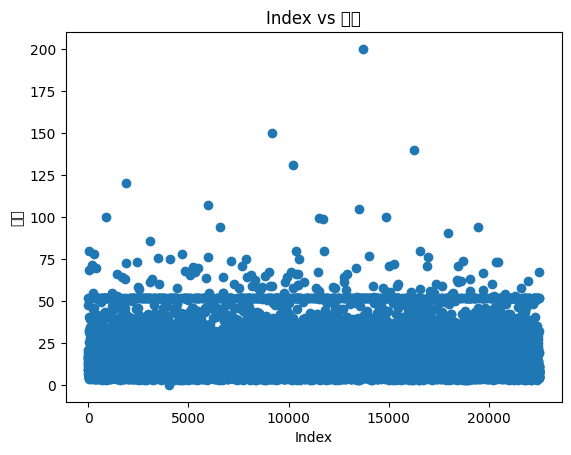

C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


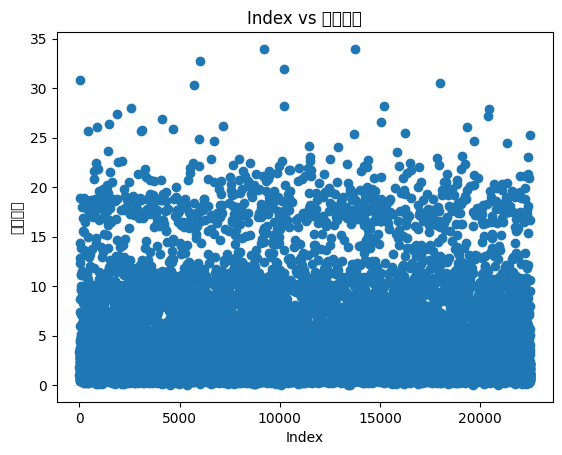

C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54017 (\N{HANGUL SYLLABLE TIB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


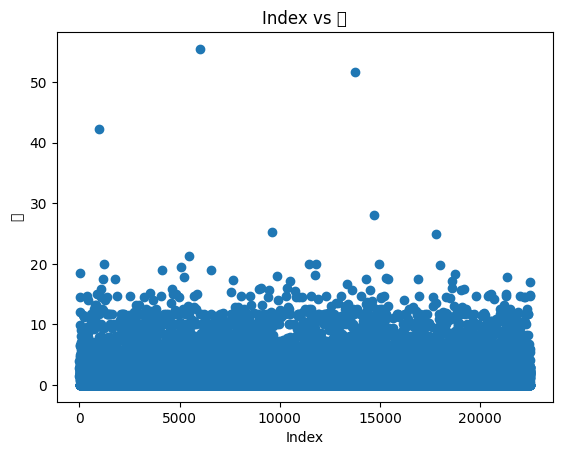

C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53672 (\N{HANGUL SYLLABLE TOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


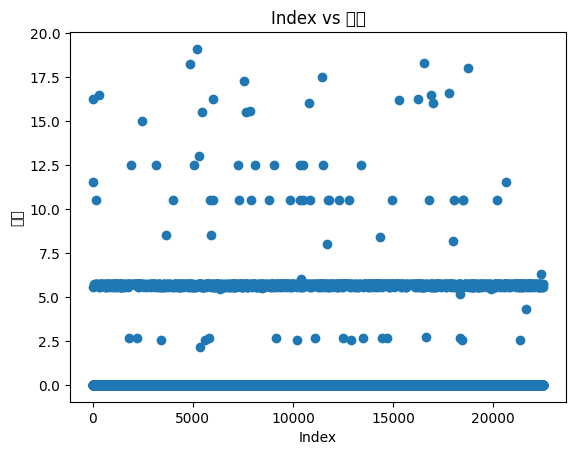

In [24]:
plt.scatter(df.index, df['요금']) #산점도 분포를 전 후로 비교해봄. 크게 차이는 안남.
plt.title('Index vs 요금')
plt.xlabel('Index')
plt.ylabel('요금')
plt.show()

plt.scatter(df.index, df['이동거리'])
plt.title('Index vs 이동거리')
plt.xlabel('Index')
plt.ylabel('이동거리')
plt.show()

plt.scatter(df.index, df['팁'])
plt.title('Index vs 팁')
plt.xlabel('Index')
plt.ylabel('팁')
plt.show()

plt.scatter(df.index, df['톨비'])
plt.title('Index vs 톨비')
plt.xlabel('Index')
plt.ylabel('톨비')
plt.show()

In [25]:
df.head(10)

,승객이름,승차시각,하차시각,결제방식,승객수,이동거리,요금,팁,톨비,총요금,주행시간,주행시간_분,이동거리km,속력
0,Pamela Duffy,2017-03-25 08:55:43,2017-03-25 09:09:47,Debit Card,6,3.34,13.0,2.76,0.0,15.76,0 days 00:14:04,14.066667,5.375196,22.927375
1,Michelle Foster,2017-04-11 14:53:28,2017-04-11 15:19:58,Debit Card,1,1.80,16.0,4.00,0.0,20.00,0 days 00:26:30,26.500000,2.896812,6.558820
2,Tina Combs,2017-12-15 07:26:56,2017-12-15 07:34:08,Debit Card,1,1.00,6.5,1.45,0.0,7.95,0 days 00:07:12,7.200000,1.609340,13.411167
3,Anthony Ray,2017-05-07 13:17:59,2017-05-07 13:48:14,Cash,1,3.70,20.5,6.39,0.0,26.89,0 days 00:30:15,30.250000,5.954558,11.810694
4,Brianna Johnson,2017-04-15 23:32:20,2017-04-15 23:49:03,Debit Card,1,4.37,16.5,0.00,0.0,16.50,0 days 00:16:43,16.716667,7.032816,25.242410
5,Justin Smith,2017-03-25 20:34:11,2017-03-25 20:42:11,Debit Card,6,2.30,9.0,2.06,0.0,11.06,0 days 00:08:00,8.000000,3.701482,27.761115
6,Tonya Moreno,2017-05-03 19:04:09,2017-05-03 20:03:47,Cash,1,12.83,47.5,9.86,0.0,57.36,0 days 00:59:38,59.633333,20.647832,20.774789
7,Hannah Foley,2017-08-15 17:41:06,2017-08-15 18:03:05,Debit Card,1,2.98,16.0,1.78,0.0,17.78,0 days 00:21:59,21.983333,4.795833,13.089461
8,Katie Whitney,2017-02-04 16:17:07,2017-02-04 16:29:14,Cash,1,1.20,9.0,0.00,0.0,9.00,0 days 00:12:07,12.116667,1.931208,9.563066
9,Amanda Jones,2017-11-10 15:20:29,2017-11-10 15:40:55,Cash,1,1.60,13.0,2.75,0.0,15.75,0 days 00:20:26,20.433333,2.574944,7.561010


In [26]:
#실습3
cols = ['이동거리', '주행시간_분', '요금', '총요금', '속력']

df[cols].corr() #이동거리와 요금이 상관관계가 높았음.

,이동거리,주행시간_분,요금,총요금,속력
이동거리,1.000000,0.154355,0.945416,0.938243,0.652918
주행시간_분,0.154355,1.000000,0.175997,0.167389,-0.044931
요금,0.945416,0.175997,1.000000,0.984034,0.506009
총요금,0.938243,0.167389,0.984034,1.000000,0.511384
속력,0.652918,-0.044931,0.506009,0.511384,1.000000


C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG})

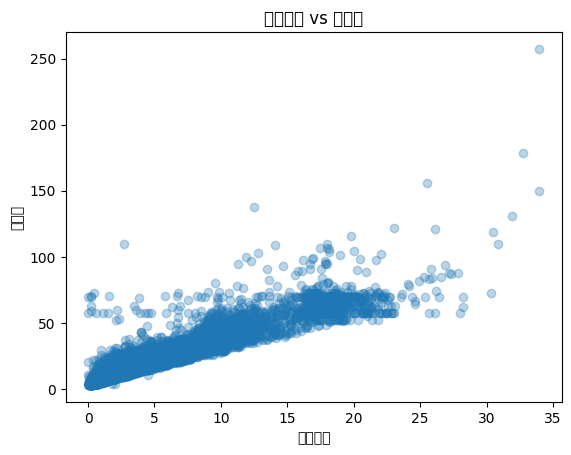

C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82104\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN})

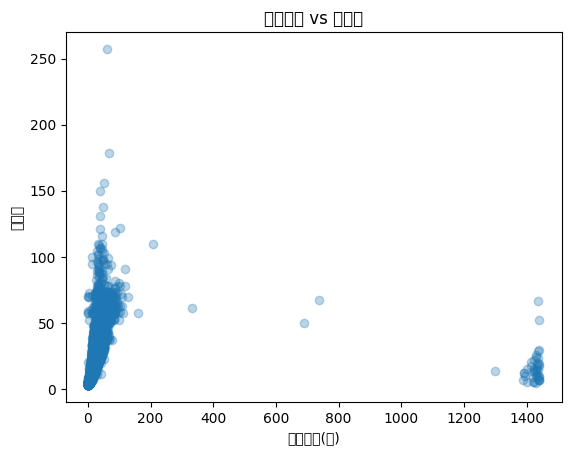

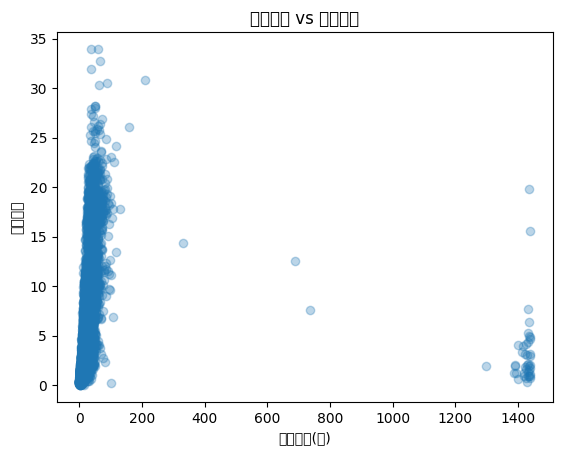

In [27]:
#산점도 거리 증가에 따라 요금이 전반적으로 증가하는 패턴이 뚜렷하게 보임.
plt.scatter(df['이동거리'], df['총요금'], alpha=0.3)
plt.xlabel('이동거리')
plt.ylabel('총요금')
plt.title('이동거리 vs 총요금')
plt.show()

#분산이 크고 일정하지 못함.
plt.scatter(df['주행시간_분'], df['총요금'], alpha=0.3)
plt.xlabel('주행시간(분)')
plt.ylabel('총요금')
plt.title('주행시간 vs 총요금')
plt.show()

#분산이 크고 일정하지 못함.
plt.scatter(df['주행시간_분'], df['이동거리'], alpha=0.3)
plt.xlabel('주행시간(분)')
plt.ylabel('이동거리')
plt.title('주행시간 vs 이동거리')
plt.show()

In [28]:
#실습4 Credit Card와 Debit Card를 구분없이 "Card"라는 이름으로 만들어 보세요.

df['결제방식'].unique()

array(['Debit Card', 'Cash', 'Credit Card'], dtype=object)

In [29]:
df['결제방식']= df['결제방식'].replace({
    'Credit Card': 'Card',
    'Debit Card': 'Card'
    })

#카드 결제 종류를 단순화하며 Card와 Cash만 남도록 정리함.

In [30]:
print(df['결제방식'].value_counts())

결제방식
Card    11368
Cash    11045
Name: count, dtype: int64


In [31]:
print(df.info()) #마무리 점검단계
print(df.describe())
print(df.head())
print(df.tail())

<class 'pandas.core.frame.DataFrame'>
Index: 22413 entries, 0 to 22501
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype          
---  ------  --------------  -----          
 0   승객이름    22413 non-null  object         
 1   승차시각    22413 non-null  datetime64[ns] 
 2   하차시각    22413 non-null  datetime64[ns] 
 3   결제방식    22413 non-null  object         
 4   승객수     22413 non-null  int64          
 5   이동거리    22413 non-null  float64        
 6   요금      22413 non-null  float64        
 7   팁       22413 non-null  float64        
 8   톨비      22413 non-null  float64        
 9   총요금     22413 non-null  float64        
 10  주행시간    22413 non-null  timedelta64[ns]
 11  주행시간_분  22413 non-null  float64        
 12  이동거리km  22413 non-null  float64        
 13  속력      22413 non-null  float64        
dtypes: datetime64[ns](2), float64(8), int64(1), object(2), timedelta64[ns](1)
memory usage: 2.6+ MB
None
                                승차시각                           하차시각  \